In [ ]:

!pip install tensorflow 
!pip install matplotlib
!pip install seaborn
import zipfile
import os
import glob
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [7]:
train_zip_path = r"D:\ECS_Aruna\train.zip"
test_zip_path = r"D:\ECS_Aruna\test.zip"

train_extract_root = r"D:\ECS_Aruna\train_extract"
test_extract_root = r"D:\ECS_Aruna\test_extract"

os.makedirs(train_extract_root, exist_ok=True)
os.makedirs(test_extract_root, exist_ok=True)

In [9]:
with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
    zip_ref.extractall(train_extract_root)

with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
    zip_ref.extractall(test_extract_root)

In [23]:
train_files = glob.glob(os.path.join(train_extract_root, "**", "*.csv"), recursive=True)
test_files = glob.glob(os.path.join(test_extract_root, "**", "*.csv"), recursive=True)

print(f"Found {len(train_files)} train CSVs")
print(f"Found {len(test_files)} test CSVs")

# Calculate total rows for training files
total_train_rows = 0
for file in train_files:
    try:
        df = pd.read_csv(file)
        total_train_rows += len(df)
    except Exception as e:
        print(f"Could not read {file}: {e}")

# Calculate total rows for testing files
total_test_rows = 0
for file in test_files:
    try:
        df = pd.read_csv(file)
        total_test_rows += len(df)
    except Exception as e:
        print(f"Could not read {file}: {e}")

print(f"\nTotal rows in all training files: {total_train_rows:,}")
print(f"Total rows in all testing files: {total_test_rows:,}")

Found 50 train CSVs
Found 22 test CSVs

Total rows in all training files: 6,953,536
Total rows in all testing files: 1,818,021


Loading and Preprocessing

In [31]:
def load_client_data(files):
    client_data = {}
    for file in files:
        try:
            df = pd.read_csv(file)
            df.fillna(0, inplace=True)
            df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
            label = 0 if "Benign" in os.path.basename(file) else 1
            df["label"] = label
            client_name = os.path.basename(file).split('_')[0]
            if client_name not in client_data:
                client_data[client_name] = []
            client_data[client_name].append(df)
        except Exception as e:
            print(f"Error loading {file}: {e}")
    # Concatenate data for each client
    for name, dfs in client_data.items():
        client_data[name] = pd.concat(dfs, ignore_index=True)
    return client_data

client_train_dfs = load_client_data(train_files)
client_test_dfs = load_client_data(test_files)

# --- Row Counting Section ---
print("\n--- Calculating Total Rows ---")
total_train_rows = sum(len(df) for df in client_train_dfs.values())
print(f"✅ Total rows in all training files: {total_train_rows:,}")
total_test_rows = sum(len(df) for df in client_test_dfs.values())
print(f"✅ Total rows in all testing files: {total_test_rows:,}\n")

print("\n--- Number of Samples per Test Client ---")
for name, test_df in client_test_dfs.items():
    print(f"Test Client '{name}': {len(test_df):,} samples")
print("-" * 40 + "\n")


--- Calculating Total Rows ---
✅ Total rows in all training files: 6,953,536
✅ Total rows in all testing files: 1,818,021


--- Number of Samples per Test Client ---
Test Client 'ARP': 1,744 samples
Test Client 'Benign': 37,607 samples
Test Client 'MQTT-DDoS-Connect': 41,916 samples
Test Client 'MQTT-DDoS-Publish': 8,416 samples
Test Client 'MQTT-DoS-Connect': 3,131 samples
Test Client 'MQTT-DoS-Publish': 17,010 samples
Test Client 'Recon-OS': 3,834 samples
Test Client 'Recon-Ping': 186 samples
Test Client 'Recon-Port': 22,622 samples
Test Client 'Recon-VulScan': 1,034 samples
Test Client 'TCP': 1,680,521 samples
----------------------------------------



In [24]:
all_train_data = []

for file in train_files:
    try:
        df = pd.read_csv(file)
        df.fillna(0, inplace=True)
        df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
        label = 0 if "Benign" in os.path.basename(file) else 1
        df["label"] = label
        all_train_data.append(df)
    except Exception as e:
        print(f"Error loading {file}: {e}")
        dummy_df = pd.DataFrame({"label": [1 if "Benign" not in file else 0]})
        all_train_data.append(dummy_df)

combined_df = pd.concat(all_train_data, ignore_index=True)
combined_df.fillna(0, inplace=True)

# Scale features
feature_columns = [col for col in combined_df.columns if col != "label"]
scaler = StandardScaler()
combined_df[feature_columns] = scaler.fit_transform(combined_df[feature_columns])

# Split data for clients
num_clients = 5
client_dataframes = np.array_split(combined_df, num_clients)
clients_data = {f"client_{i+1}": df for i, df in enumerate(client_dataframes)}
print("\n--- Number of Samples per Client ---")
for name, client_df in clients_data.items():
    print(f"Client '{name}': {len(client_df):,} samples")
print("-" * 36 + "\n")


d:\ECS_Aruna\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)



--- Number of Samples per Client ---
Client 'client_1': 1,390,708 samples
Client 'client_2': 1,390,707 samples
Client 'client_3': 1,390,707 samples
Client 'client_4': 1,390,707 samples
Client 'client_5': 1,390,707 samples
------------------------------------



Model Building

In [13]:
def create_tf_dataset(X, y, batch_size=32):
    return tf.data.Dataset.from_tensor_slices((X, y)).shuffle(1024).batch(batch_size).prefetch(tf.data.AUTOTUNE)

def create_model(input_dim, lr):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


Cyclical Learning Rate Function

In [14]:
def get_cyclic_lr(round_num, base_lr=0.0005, max_lr=0.05, step_size=3):
    cycle = np.floor(1 + round_num / (2 * step_size))
    x = np.abs(round_num / step_size - 2 * cycle + 1)
    return base_lr + (max_lr - base_lr) * max(0, (1 - x))


Prepare Client Datasets

In [15]:
client_train_data, client_sizes = {}, {}
input_dim = None

for name, df in clients_data.items():
    X = df.drop(columns=["label"]).values
    y = df["label"].values
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.3, random_state=42)
    if input_dim is None:
        input_dim = X.shape[1]
    client_train_data[name] = (X_train, y_train)
    client_sizes[name] = len(X_train)

total_samples = sum(client_sizes.values())


Federated Learning Training

In [16]:
# Track metrics
global_train_loss_per_round = []
global_val_acc_per_round = []
local_train_accuracies = {name: [] for name in client_train_data.keys()}
local_val_accuracies = {name: [] for name in client_train_data.keys()}
avg_train_accuracies_per_round = []

global_model = create_model(input_dim, lr=0.01)
NUM_ROUNDS = 20

for round_num in range(NUM_ROUNDS):
    print(f"\n--- Round {round_num + 1} ---")
    client_weights = []
    client_weight_factors = []
    current_lr = get_cyclic_lr(round_num)

    round_losses = []
    round_val_accs = []
    round_train_accs = []

    for name, (X, y) in client_train_data.items():
        local_model = create_model(input_dim, lr=current_lr)
        local_model.set_weights(global_model.get_weights())

        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=round_num)
        train_ds = create_tf_dataset(X_train, y_train)
        val_ds = create_tf_dataset(X_val, y_val)

        history = local_model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=10,
            verbose=0,
            callbacks=[EarlyStopping(patience=2, restore_best_weights=True)]
        )

        final_train_loss = history.history["loss"][-1]
        final_train_acc = history.history["accuracy"][-1]
        final_val_acc = history.history["val_accuracy"][-1]

        local_train_accuracies[name].append(final_train_acc)
        local_val_accuracies[name].append(final_val_acc)
        round_losses.append(final_train_loss)
        round_val_accs.append(final_val_acc)
        round_train_accs.append(final_train_acc)

        client_weights.append(local_model.get_weights())
        client_weight_factors.append(client_sizes[name] / total_samples)

    # Federated Averaging
    new_weights = []
    for weights in zip(*client_weights):
        avg = sum(w * f for w, f in zip(weights, client_weight_factors))
        new_weights.append(avg)
    global_model.set_weights(new_weights)

    avg_loss = np.average(round_losses, weights=client_weight_factors)
    avg_val_acc = np.average(round_val_accs, weights=client_weight_factors)
    avg_train_acc = np.average(round_train_accs, weights=client_weight_factors)

    global_train_loss_per_round.append(avg_loss)
    global_val_acc_per_round.append(avg_val_acc)
    avg_train_accuracies_per_round.append(avg_train_acc)

    print(f"Train Loss: {avg_loss:.4f} | Val Accuracy: {avg_val_acc:.4f} | Avg Train Acc: {avg_train_acc:.4f}")



--- Round 1 ---
Train Loss: 0.0060 | Val Accuracy: 0.9975 | Avg Train Acc: 0.9973

--- Round 2 ---
Train Loss: 0.0081 | Val Accuracy: 0.9969 | Avg Train Acc: 0.9963

--- Round 3 ---
Train Loss: 0.0158 | Val Accuracy: 0.9951 | Avg Train Acc: 0.9950

--- Round 4 ---
Train Loss: 0.0281 | Val Accuracy: 0.9942 | Avg Train Acc: 0.9903

--- Round 5 ---
Train Loss: 0.0179 | Val Accuracy: 0.9951 | Avg Train Acc: 0.9946

--- Round 6 ---
Train Loss: 0.0074 | Val Accuracy: 0.9968 | Avg Train Acc: 0.9969

--- Round 7 ---
Train Loss: 0.0073 | Val Accuracy: 0.9968 | Avg Train Acc: 0.9968

--- Round 8 ---
Train Loss: 0.0074 | Val Accuracy: 0.9973 | Avg Train Acc: 0.9969

--- Round 9 ---
Train Loss: 0.0170 | Val Accuracy: 0.9955 | Avg Train Acc: 0.9948

--- Round 10 ---
Train Loss: 0.0233 | Val Accuracy: 0.9952 | Avg Train Acc: 0.9920

--- Round 11 ---
Train Loss: 0.0169 | Val Accuracy: 0.9953 | Avg Train Acc: 0.9948

--- Round 12 ---
Train Loss: 0.0074 | Val Accuracy: 0.9973 | Avg Train Acc: 0.9968



In [49]:

print("\n--- Average Training Accuracy Per Client (across all rounds) ---")

for name, acc_history in local_train_accuracies.items():
    if acc_history: # Ensure the list of accuracies is not empty
        # Calculate the average of the accuracy list for this client
        avg_acc = np.mean(acc_history)
        print(f"Client '{name}': Average Accuracy = {avg_acc * 100:.2f}%")
# -------------------------------------------


--- Average Training Accuracy Per Client (across all rounds) ---
Client 'client_1': Average Accuracy = 97.77%
Client 'client_2': Average Accuracy = 100.00%
Client 'client_3': Average Accuracy = 100.00%
Client 'client_4': Average Accuracy = 100.00%
Client 'client_5': Average Accuracy = 100.00%


In [43]:
test_data = []

for file in test_files:
    try:
        df = pd.read_csv(file)
        df.dropna(inplace=True)
        df = df.select_dtypes(include=[np.number])
        label = 0 if "Benign" in os.path.basename(file) else 1
        df["label"] = label
        test_data.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

test_df = pd.concat(test_data, ignore_index=True)
X_test = test_df.drop(columns=["label"]).values
X_test = scaler.transform(X_test)
y_test = test_df["label"].values


d:\ECS_Aruna\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



--- Combining and Splitting Test Data ---


d:\ECS_Aruna\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Combined test data into 1,818,021 total samples.

--- Number of Samples per Artificially Split Test Client ---
'test_client_1': 363,605 samples
'test_client_2': 363,604 samples
'test_client_3': 363,604 samples
'test_client_4': 363,604 samples
'test_client_5': 363,604 samples
------------------------------------------------------------

Split test data equally among 5 simulated test clients.

--- Evaluating Global Model on Each Artificially Split Test Set ---
11363/11363 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
'test_client_1': Accuracy = 97.93% | F1 = 0.9895 | AUC = 0.5000
11363/11363 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step
'test_client_2': Accuracy = 97.92% | F1 = 0.9895 | AUC = 0.5000
11363/11363 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step
'test_client_3': Accuracy = 97.94% | F1 = 0.9896 | AUC = 0.5000
11363/11363 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step
'test_client_4': Accuracy = 97.93% | F1 = 0.9896 | AUC = 0.5000
11363/11363 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step
'test_client_5': Accuracy = 97.94% | F1 = 0.9896 | 

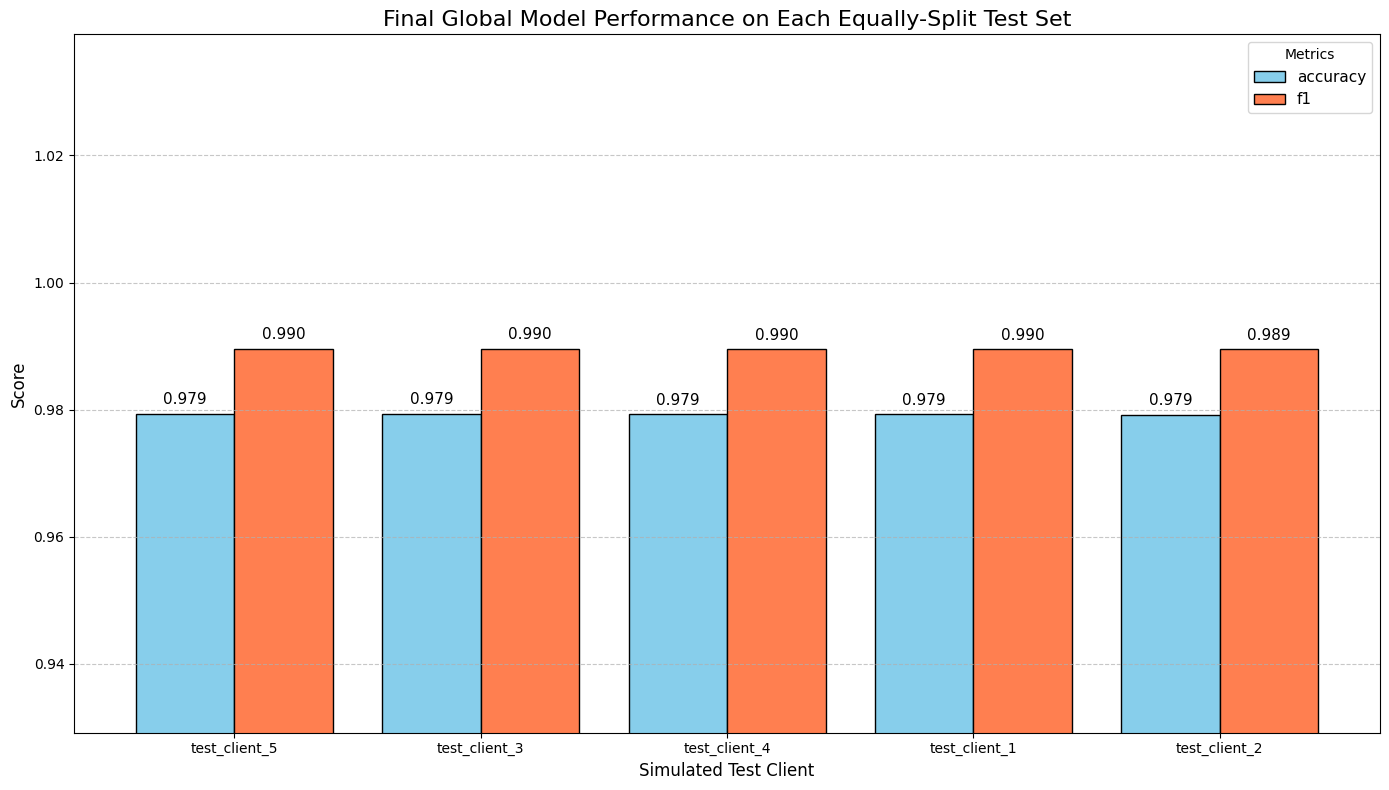

In [34]:
# === 7. FINAL EVALUATION (WITH EQUAL SPLIT FOR TEST DATA) ===

# --- 7.1: Combine all test data into one DataFrame ---
print("\n--- Combining and Splitting Test Data ---")
full_test_df = pd.concat(client_test_dfs.values(), ignore_index=True)
full_test_df.fillna(0, inplace=True) 

full_test_df = full_test_df.sample(frac=1, random_state=42).reset_index(drop=True)
# Ensure feature alignment before scaling
full_test_df_processed = pd.DataFrame(columns=feature_columns, data=full_test_df[feature_columns].values)

X_test_full = scaler.transform(full_test_df_processed.values)
y_test_full = full_test_df["label"].values

print(f"Combined test data into {len(full_test_df):,} total samples.")

# --- 7.2: Artificially split the combined test data into 5 clients ---
num_test_clients = 5
X_test_splits = np.array_split(X_test_full, num_test_clients)
y_test_splits = np.array_split(y_test_full, num_test_clients)

client_test_data_split = {f"test_client_{i+1}": (X_test_splits[i], y_test_splits[i]) for i in range(num_test_clients)}
# --- ADD THIS LOOP ---
print("\n--- Number of Samples per Artificially Split Test Client ---")
for name, (X_test_local, y_test_local) in client_test_data_split.items():
    print(f"'{name}': {len(X_test_local):,} samples")
print("-" * 60 + "\n")
print(f"Split test data equally among {num_test_clients} simulated test clients.\n")


# --- 7.3: Loop through the NEW artificially split test sets ---
print("--- Evaluating Global Model on Each Artificially Split Test Set ---")
local_test_results = {}

for name, (X_test_local, y_test_local) in client_test_data_split.items():
    if len(np.unique(y_test_local)) < 2:
        print(f"'{name}': Skipped (only one class present in this split)")
        continue

    loss, acc = global_model.evaluate(X_test_local, y_test_local, verbose=0)
    y_pred_prob_local = global_model.predict(X_test_local)
    y_pred_local = (y_pred_prob_local > 0.5).astype("int32")

    f1_local = f1_score(y_test_local, y_pred_local)
    auc_local = roc_auc_score(y_test_local, y_pred_prob_local)

    local_test_results[name] = {"accuracy": acc, "f1": f1_local, "auc": auc_local}
    print(f"'{name}': Accuracy = {acc*100:.2f}% | F1 = {f1_local:.4f} | AUC = {auc_local:.4f}")

local_test_results_df = pd.DataFrame(local_test_results).T
print("\nLocal Test Results Summary:")
print(local_test_results_df)


# === 8. PLOTTING FINAL RESULTS ===
# (The plotting code from before will work perfectly with the new 'local_test_results_df')
if not local_test_results_df.empty:
    # ... (insert the plotting code block from the previous answer here) ...
    df_to_plot = local_test_results_df[['accuracy', 'f1']]
    df_to_plot = df_to_plot.sort_values('f1', ascending=False)
    ax = df_to_plot.plot(kind='bar', figsize=(14, 8), width=0.8, color={'accuracy': 'skyblue', 'f1': 'coral'}, edgecolor='black')
    plt.title('Final Global Model Performance on Each Equally-Split Test Set', fontsize=16)
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Simulated Test Client', fontsize=12)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(bottom=max(0, df_to_plot.min().min() - 0.05))
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=11)
    plt.legend(title='Metrics', fontsize=11)
    plt.tight_layout()
    plt.show()

In [35]:
# --- Global Model on AGGREGATED Test Data ---
print("\n\n--- Evaluating Global Model on Full Aggregated Test Data ---")

# 1. Combine all client test data into one DataFrame
full_test_df = pd.concat(client_test_dfs.values(), ignore_index=True)
full_test_df.fillna(0, inplace=True) 

# 2. Prepare the data for the model
# Ensure feature columns match the training data
full_test_df_processed = pd.DataFrame(columns=feature_columns, data=full_test_df[feature_columns].values)

# Apply the same scaler used in training
X_test_full = scaler.transform(full_test_df_processed.values)
y_test_full = full_test_df["label"].values

# 3. Evaluate the model
loss, accuracy = global_model.evaluate(X_test_full, y_test_full, verbose=0)

# 4. Print the result
print(f"\n✅ Overall Global Model Accuracy: {accuracy * 100:.2f}%")

# You can also get other metrics like F1 and AUC
y_pred_prob = global_model.predict(X_test_full)
y_pred = (y_pred_prob > 0.5).astype("int32")

f1 = f1_score(y_test_full, y_pred)
auc = roc_auc_score(y_test_full, y_pred_prob)

print(f"   - F1 Score: {f1:.4f}")
print(f"   - AUC Score: {auc:.4f}\n")



--- Evaluating Global Model on Full Aggregated Test Data ---


d:\ECS_Aruna\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



✅ Overall Global Model Accuracy: 97.93%
56814/56814 ━━━━━━━━━━━━━━━━━━━━ 64s 1ms/step
   - F1 Score: 0.9895
   - AUC Score: 0.5000



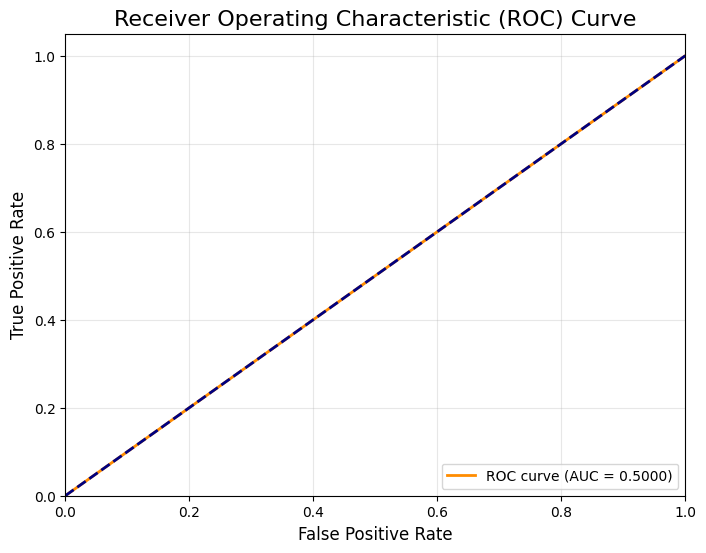

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test_full, y_pred_prob)
auc_score = roc_auc_score(y_test_full, y_pred_prob)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Dashed line for random guess
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

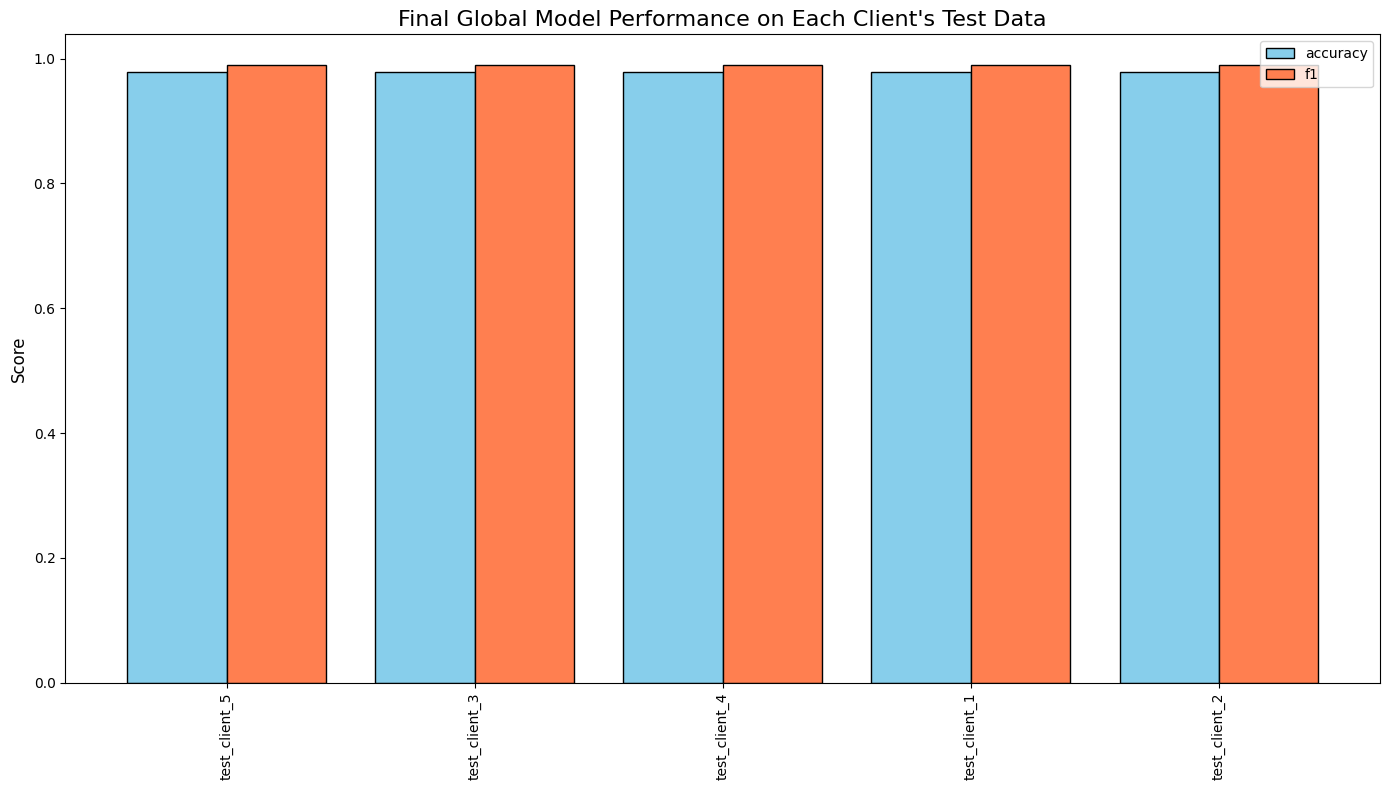

In [38]:
# (This is the same code as before, provided for convenience)
if not local_test_results_df.empty:
    df_to_plot = local_test_results_df[['accuracy', 'f1']]
    df_to_plot = df_to_plot.sort_values('f1', ascending=False)

    ax = df_to_plot.plot(kind='bar', figsize=(14, 8), width=0.8, color={'accuracy': 'skyblue', 'f1': 'coral'}, edgecolor='black')
    
    plt.title('Final Global Model Performance on Each Client\'s Test Data', fontsize=16)
    plt.ylabel('Score', fontsize=12)
    # ... (rest of the plotting code) ...
    plt.tight_layout()
    plt.show()

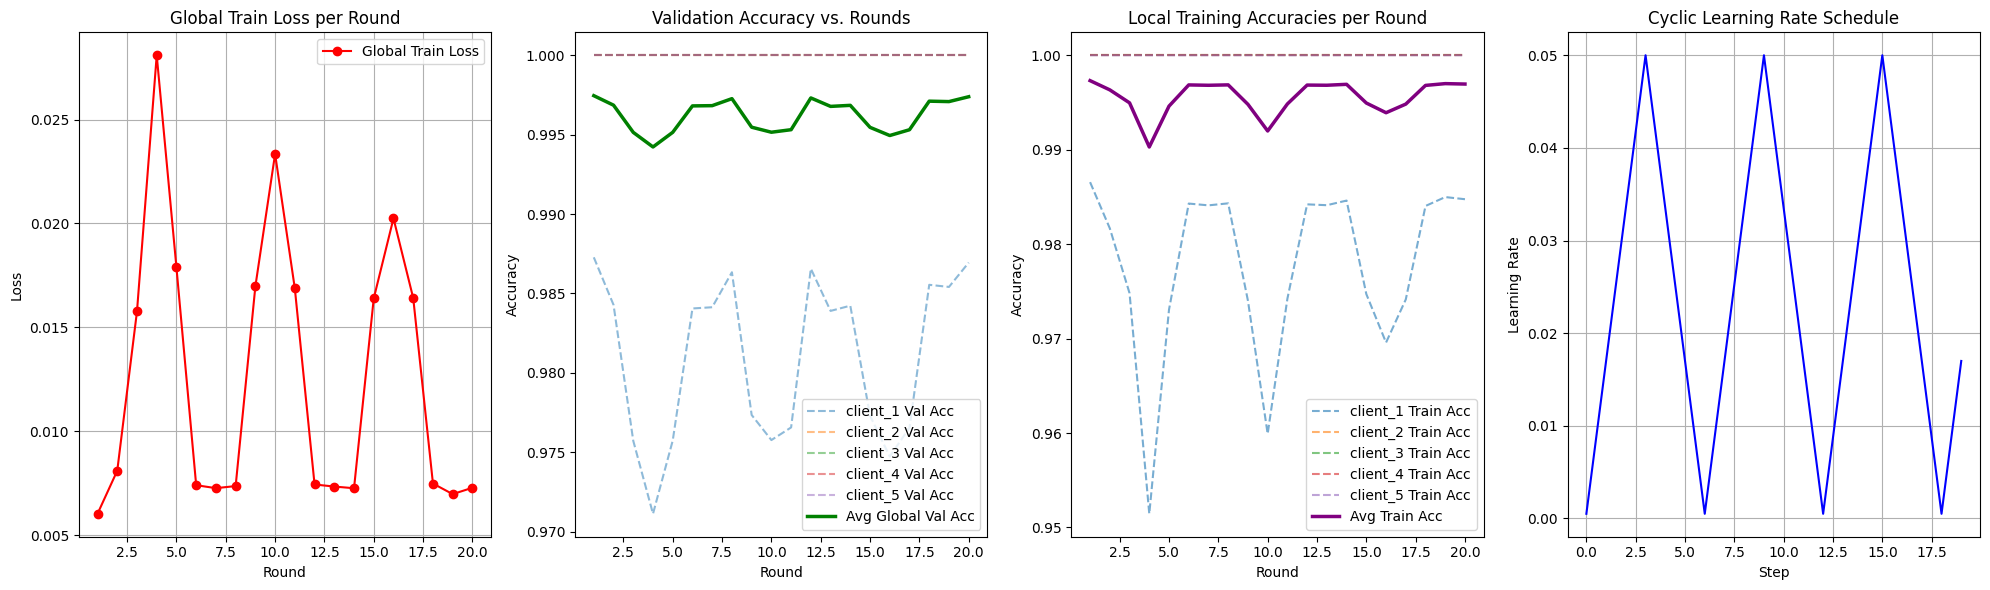

In [47]:
rounds = list(range(1, NUM_ROUNDS + 1))
plt.figure(figsize=(20, 6))

# (1) Global Training Loss
plt.subplot(1, 4, 1)
plt.plot(rounds, global_train_loss_per_round, marker='o', color='red', label='Global Train Loss')
plt.title("Global Train Loss per Round")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# (2) Validation Accuracy
plt.subplot(1, 4, 2)
for name, accs in local_val_accuracies.items():
    plt.plot(rounds, accs, linestyle='--', alpha=0.5, label=f"{name} Val Acc")
plt.plot(rounds, global_val_acc_per_round, color='green', linewidth=2.5, label="Avg Global Val Acc")
plt.title("Validation Accuracy vs. Rounds")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.legend(loc='lower right')

# (3) Local Training Accuracies
plt.subplot(1, 4, 3)
for name, accs in local_train_accuracies.items():
    plt.plot(rounds, accs, linestyle='--', alpha=0.6, label=f"{name} Train Acc")
plt.plot(rounds, avg_train_accuracies_per_round, color='purple', linewidth=2.5, label='Avg Train Acc')
plt.title("Local Training Accuracies per Round")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.legend(loc='lower right')

# (4) Cyclic Learning Rate
plt.subplot(1, 4, 4)
cyclic_lrs = [get_cyclic_lr(r-1) for r in rounds]
plt.plot(range(len(cyclic_lrs)), cyclic_lrs, color='blue')
plt.title("Cyclic Learning Rate Schedule")
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.grid(True)

plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

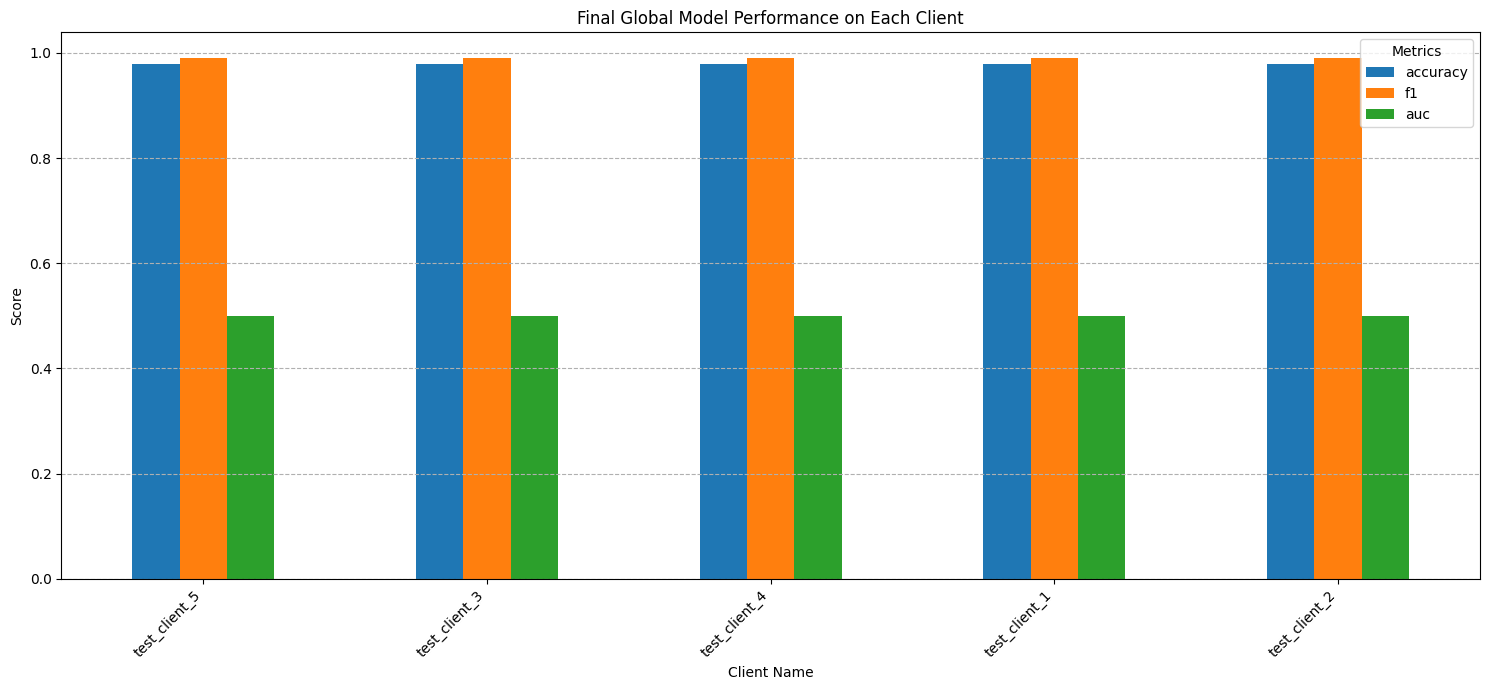

In [40]:
# Bar chart of final client results
if not local_test_results_df.empty:
    local_test_results_df.sort_values('f1', ascending=False, inplace=True) # Sort for better visualization

    plt.figure(figsize=(12, 8))
    local_test_results_df[['accuracy', 'f1', 'auc']].plot(kind='bar', figsize=(15, 7))
    plt.title('Final Global Model Performance on Each Client')
    plt.ylabel('Score')
    plt.xlabel('Client Name')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--')
    plt.legend(title='Metrics')
    plt.tight_layout()
    plt.show()

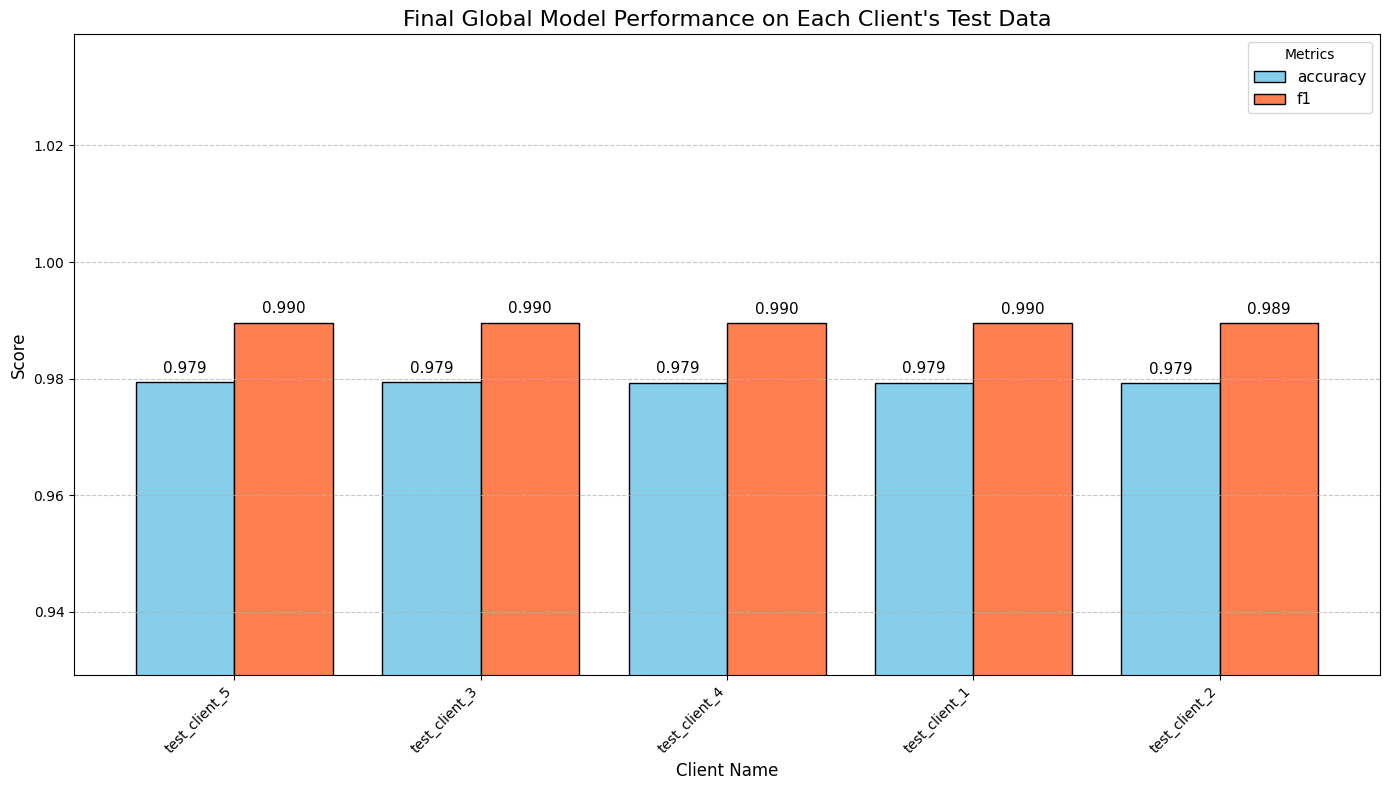

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# This code assumes your 'local_test_results_df' DataFrame already exists 
# from the evaluation cell.

if not local_test_results_df.empty:
    # Select only the Accuracy and F1 score for the plot
    df_to_plot = local_test_results_df[['accuracy', 'f1']]
    
    # Sort by F1 score for a cleaner presentation
    df_to_plot = df_to_plot.sort_values('f1', ascending=False)

    # Create the bar plot using pandas' built-in plotting function
    ax = df_to_plot.plot(kind='bar', 
                         figsize=(14, 8), 
                         width=0.8,
                         color={'accuracy': 'skyblue', 'f1': 'coral'},
                         edgecolor='black')

    # Add labels and a title for clarity
    plt.title('Final Global Model Performance on Each Client\'s Test Data', fontsize=16)
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Client Name', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Add a light grid on the y-axis
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Set y-axis limits to zoom in on the results if they are close
    plt.ylim(bottom=max(0, df_to_plot.min().min() - 0.05))

    # Add the exact score on top of each bar for easy reading
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=11)

    plt.legend(title='Metrics', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("The 'local_test_results_df' DataFrame is empty. Please run the evaluation cell first.")

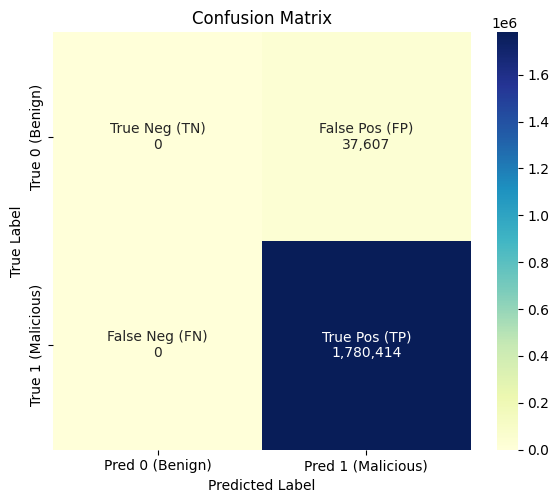

In [42]:
cm = confusion_matrix(y_test, y_pred)
group_names = ['True Neg (TN)', 'False Pos (FP)', 'False Neg (FN)', 'True Pos (TP)']
group_counts = [f"{value:,.0f}" for value in cm.flatten()]
box_labels = [f"{name}\n{count}" for name, count in zip(group_names, group_counts)]
box_labels = np.asarray(box_labels).reshape(2, 2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=box_labels, fmt='', cmap='YlGnBu', cbar=True, square=True,
            xticklabels=['Pred 0 (Benign)', 'Pred 1 (Malicious)'],
            yticklabels=['True 0 (Benign)', 'True 1 (Malicious)'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()